# **Primer proyecto de Machine Learning: Regresión Logística**

En **Machine Learning**, el algoritmo de **regresión logística** es un **algoritmo de clasificación**, **no** de regresión, a pesar de su nombre confuso.

### ¿Por qué se llama "regresión" si clasifica?

El nombre viene de sus orígenes en estadística, donde se utilizaba una transformación logística sobre una regresión lineal para modelar probabilidades. Sin embargo, su uso principal en ML es para:

* **Clasificación binaria**: por ejemplo, predecir si un email es *spam* o *no spam*.
* También se puede extender a **clasificación multiclase** mediante estrategias como **one-vs-rest**.

### ¿Cómo funciona?

* Modela la probabilidad de pertenencia a una clase.
* La salida es continua (una probabilidad entre 0 y 1), pero se **umbraliza** (por ejemplo, a 0.5) para decidir la clase.
* Utiliza la **función sigmoide** para convertir una combinación lineal de características en una probabilidad.

### En resumen:

| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |

### Hiperparámetros:

Podemos construir un modelo de regresión logística fácilmente en Python utilizando la librería `scikit-learn` y la función `LogisticRegression`.

Algunos de sus parámetros más importantes y los primeros en los que debemos centrarnos son:

- `penalty`: Este parámetro se usa para prevenir el sobreajuste (*overfitting*) del modelo. Este parámetro se puede configurar para que no exista penalización y para graduarla desde niveles muy leves hasta muy altos.

- `C`: Este parámetro determina la complejidad del modelo. Es el inverso del parámetro anterior. Es un número decimal que determina cómo de simple queremos que sea el modelo. Cuanto mayor sea el número, más complejo será el modelo y más se adaptará a la muestra de entrenamiento (aumentando la probabilidad del [sobreajuste](https://4geeks.com/es/lesson/basicos-de-machine-learning#Sobreajuste-de-modelos)).

- `solver`: Algoritmo de regresión que se utilizará para entrenar al modelo. Dependiendo del tamaño del conjunto de datos, de las clases a predecir, del nivel de sobreajuste que estemos dispuestos a asumir o del nivel de precisión, elegiremos una implementación u otra.

- `max_iter`: Número máximo de iteraciones.

Otro parámetro muy importante es el `random_state`, que controla la semilla de generación aleatoria que requieren algunos de los solvers del modelo. Este parámetro es crucial para asegurar la replicabilidad.

# **Paso 0: Imports de librerías**

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


In [82]:
def warn(*args, **kwargs):
    pass


warnings.warn = warn

# **EDA** : Análisis de datos bancarios

## PASO 1. **Leer la data y crear el data frame**

In [53]:
df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


###  **Comprensión de las variables del proyecto**

1. INFORMACIÓN DEL CLIENTE:
> * ``age.`` Edad del cliente (numérico)
> * ``job.`` Tipo de trabajo (categórico)
> * ``marital.`` Estado civil (categórico)
> * ``education.`` Nivel de educación (categórico)
2. INFORMACIÓN BANCÁRIA DEL CLIENTE:
> * ``default.`` ¿Tiene crédito actualmente? (categórico)
> * ``housing.`` ¿Tiene un préstamo de vivienda? (categórico)
> * ``loan.`` ¿Tiene un préstamo personal? (categórico)
3. INFORMACIÓN DE CONTACTO CON EL CLIENTE DURANTE LA ÚLTIMA CAMPAÑA:
> * ``contact.`` Tipo de comunicación de contacto (categórico)
> * ``month.`` Último mes en el que se le ha contactado (categórico)
> * ``day_of_week.`` Último día en el que se le ha contactado (categórico)
> * ``duration.`` Duración del contacto previo en segundos (numérico)
> * ``campaign.`` Número de contactos realizados durante esta campaña al cliente (numérico)
> * ``pdays.`` Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
> * ``previous.`` Número de contactos realizados durante la campaña anterior al cliente (numérico)
> * ``poutcome.`` Resultado de la campaña de marketing anterior (categórico)
4. INDICADORES DE ECONOMÍA SOCIAL:
> * ``emp.var``.rate. Tasa de variación del empleo. Indicador trimestral (numérico)
> * ``cons.price``.idx. Índice de precios al consumidor. Indicador mensual (numérico)
> * ``cons.conf``.idx. Índice de confianza del consumidor. Indicador mensual (numérico)
> * ``euribor3m.`` Tasa EURIBOR 3 meses. Indicador diario (numérico)
> * ``nr.employed`` Número de empleados. Indicador trimestral (numérico)
5. **VARIABLE TARGET**
> * ``y`` El cliente contrata un depósito a largo plazo o no (categórico)


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### **Comprensión empresarial**



Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

* **Descripción del problema**

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

* **Objetivo**
Identificar a los clientes con mayor proporcionados en la lista que tienen mayor probabilidad de contratar un depósito a largo plazo.  
Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.  

**Conclusión:**

Para analizar del conjunto de datos el objetivo será identificar las variables con mayor relación a la información del cliente para así poder buscar cuales son los usuarios potenciales y qué otros datos del conjunto se relacionan más con ellos.



## PASO 1. **Información de la data**

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 41188 filas y 21 columnas  
> * Los datos que aporta el datset son 10 columnas de tipo numérico (enteros y decimales) y 11 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(5), int64(5), object(11)``  

> 2. DESCRIPCIÓN ESTADÍSTICA INICIAL:

* **Variable Target**

In [56]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [57]:
# Media de clientes que ya tienen contratado el servicio
total_yes = df[df['y']=='yes'].value_counts().sum()
mean_yes = (total_yes / len(df) * 100)

# Media de clientes que no han contratado anteriormente un depósito a largo plazo
total_no = df[df['y']=='no'].value_counts().sum()
mean_no = (total_no / len(df) * 100)


In [58]:
mean_no, mean_yes

(np.float64(88.73458288821988), np.float64(11.265417111780131))

**Conclusión:**
> * La mayoría de los clientes no tienen contratado ese servicio y la campaña anterior no obtuvo buenos resultados positivos.
> * El 88.74% de los clientes del data set no contrataron el servicio en la pasaqda campaña, solamente el 11.26% sí lo hizo.

## PASO 2. **Limpieza de datos**

#### **Eliminar duplicados**

In [59]:
df_dupl = df[df.duplicated(subset=df.columns, keep= False)]
df_dupl

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [60]:
# Elimino los duplicados comparando la informacion de las columnas y se conserva 1 fila de la data repetida para no perder la información
df = df.drop_duplicates(subset=df.columns)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [61]:
# Compruebo si quedan duplicados
df.duplicated().sum()

np.int64(0)

#### **Comprobar valores nulos**

In [62]:
# Compruebo si hay datos nulos (faltantes)
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

#### **Conclusión de la limpieza de datos:**

> VALORES NULOS Y DUPLICADOS:
> * Las columnas no contienen valores nulos y hay 24 filas duplicadas que ya han sido eliminadas.
> * Filas duplicadas: ¿Es posible que existan dos clientes con los mismos datos?  
En el ds no tenemos una columna idewntificadora por cliente en este caso asi que interpreto que las filas duplicadas son distintas llamadas al mismo cliente y elimino los duplicados.

## PASO 4. **Análisis de las variables**

Decido analizar algunas variables buscando el perfil del cliente qué más ha contratado el depósito a largo plazo. Para ello analizo algunas columnas:

#### **Cons.con.idx**

In [63]:
df[df['cons.price.idx']>65].value_counts().sum()

np.int64(41176)

In [64]:
df[df['cons.price.idx']<25].value_counts()

Series([], Name: count, dtype: int64)

#### **Housing**

In [65]:
df['housing'].value_counts()

housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

**Observaciones:**

> * Existen 215.571 clientes que ya han contratado un depósito.
> * De lo clientes actuales 19.615 nunca han contratado un depósito a largo plazo
> * Del resto de clientes (990), no sabemos si lo hicieron o no

**Conclusión del gráfico:**
> * Tomo esta variable para ver a qué se dedican las personas que más han contratado un depósito anteriormente
> * Housing indica si el cliente tiene un préstamo de vivienda. Es una vatiable Categórica ¿?

### **ANÁLISIS UNIVARIANTE**

#### **Análisis variables categóricas**

* ``Función: .countplot()`` , analiza bien los datos categóricos dsicretos pero si pasamos vairables numéricas continuas(tiempo, medidas métricas,...) el gráfico no se podrá interpretar bien debido al número de particiones posibles  
Codifico un subconjunto con las columnas categóricas discretas:

In [66]:
categorical_discret_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]

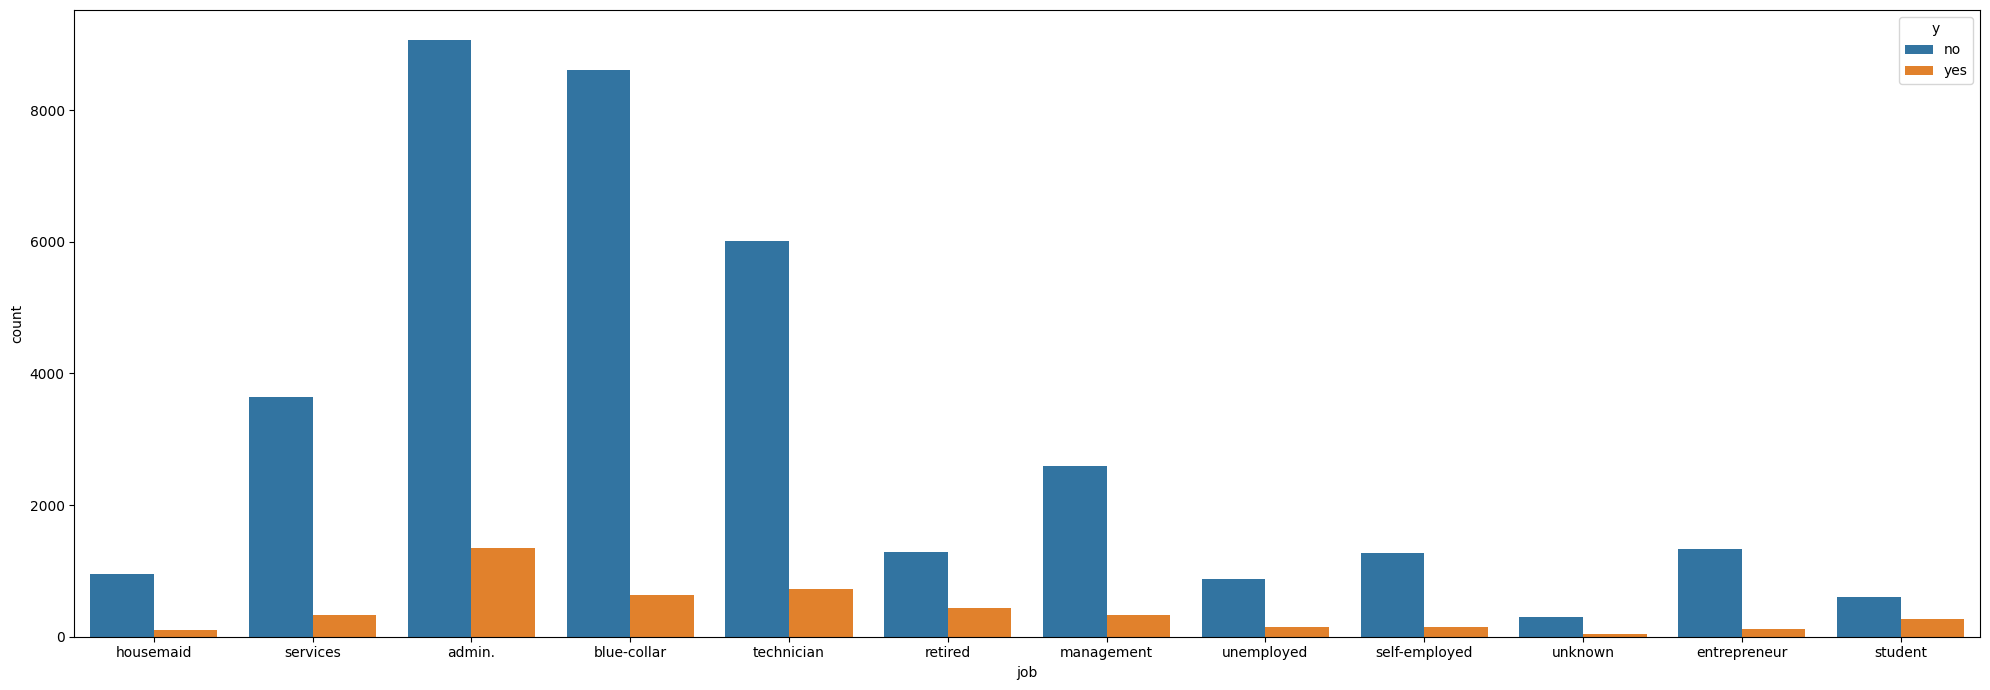

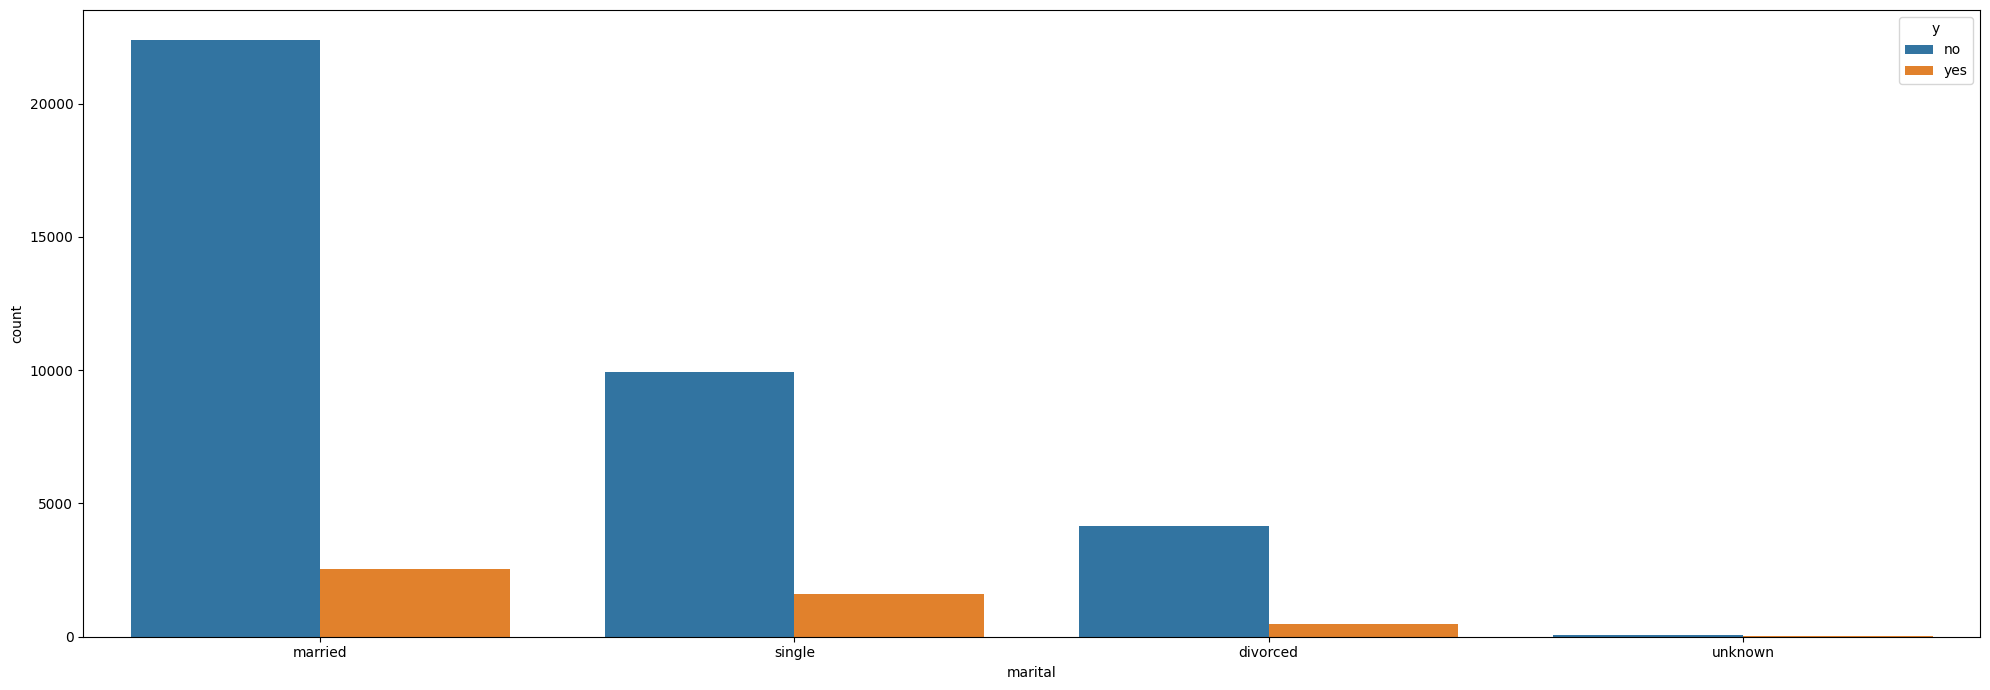

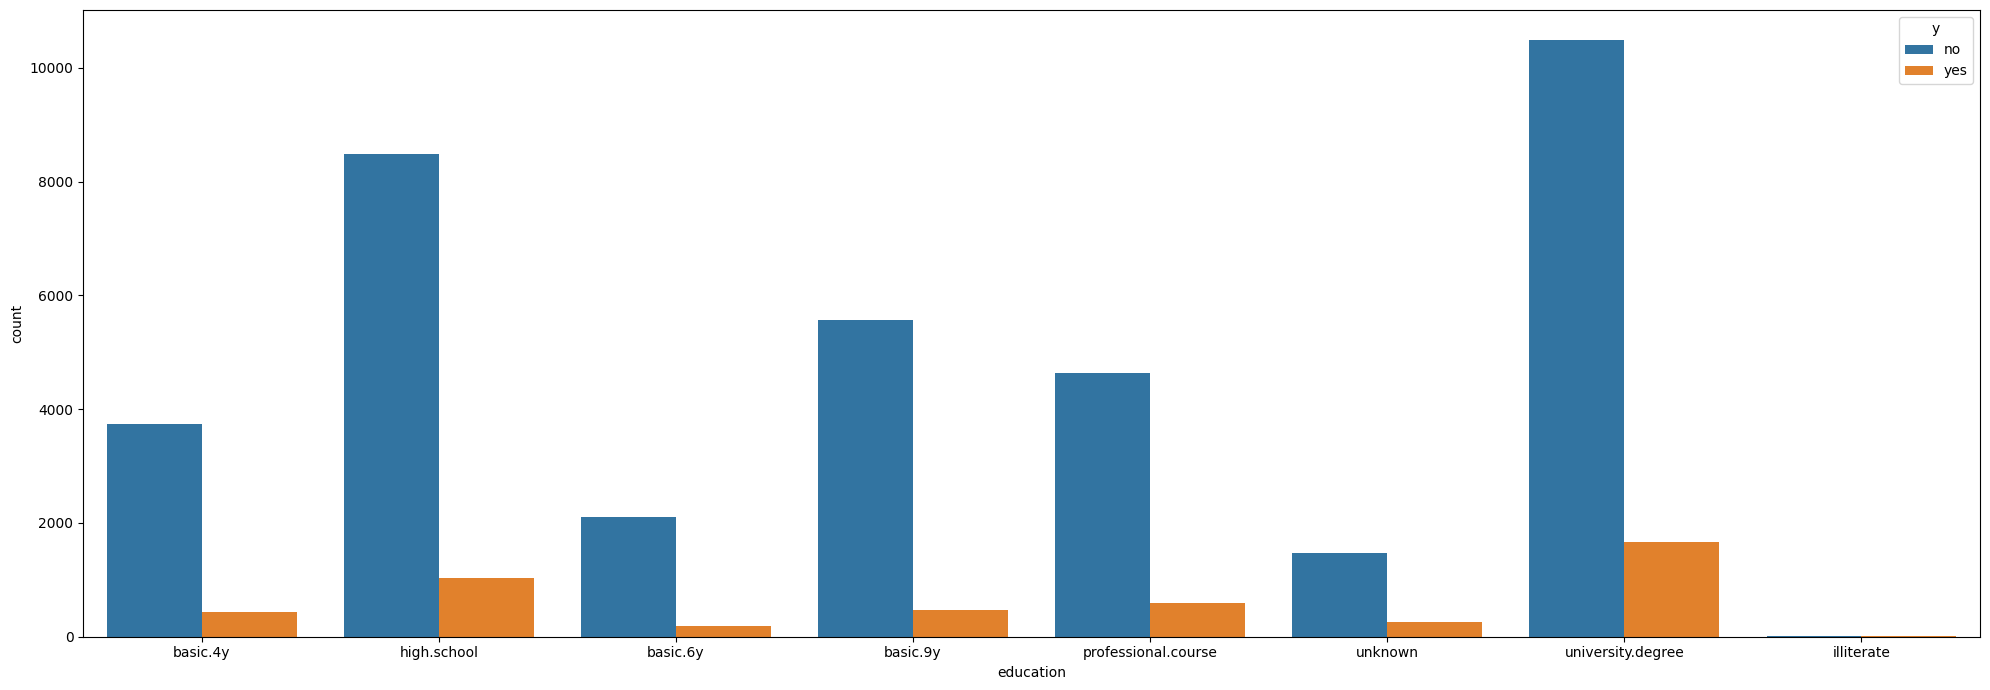

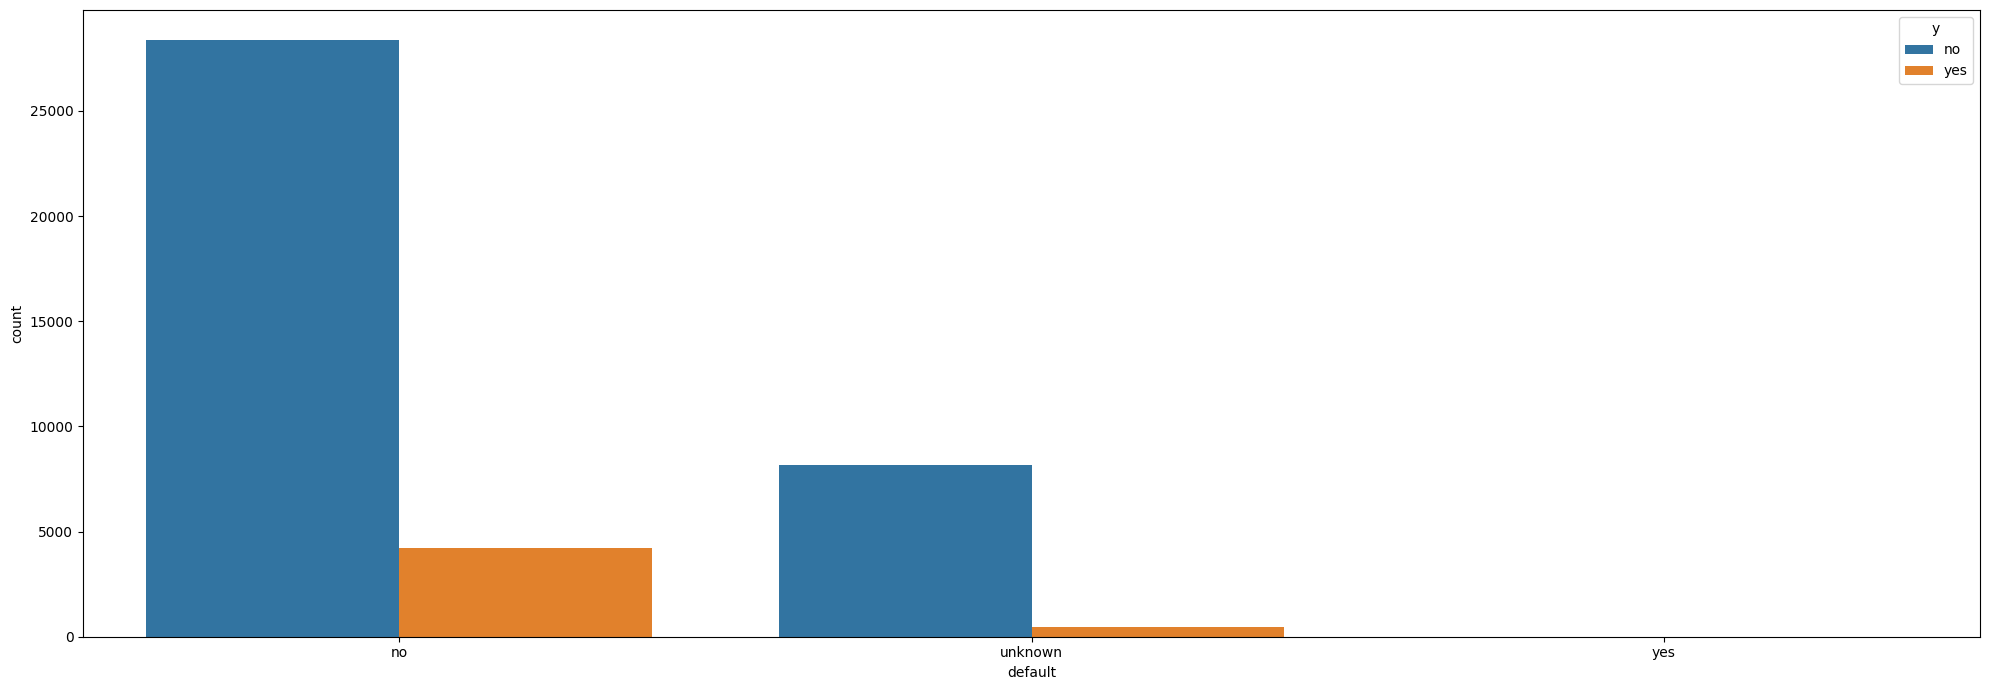

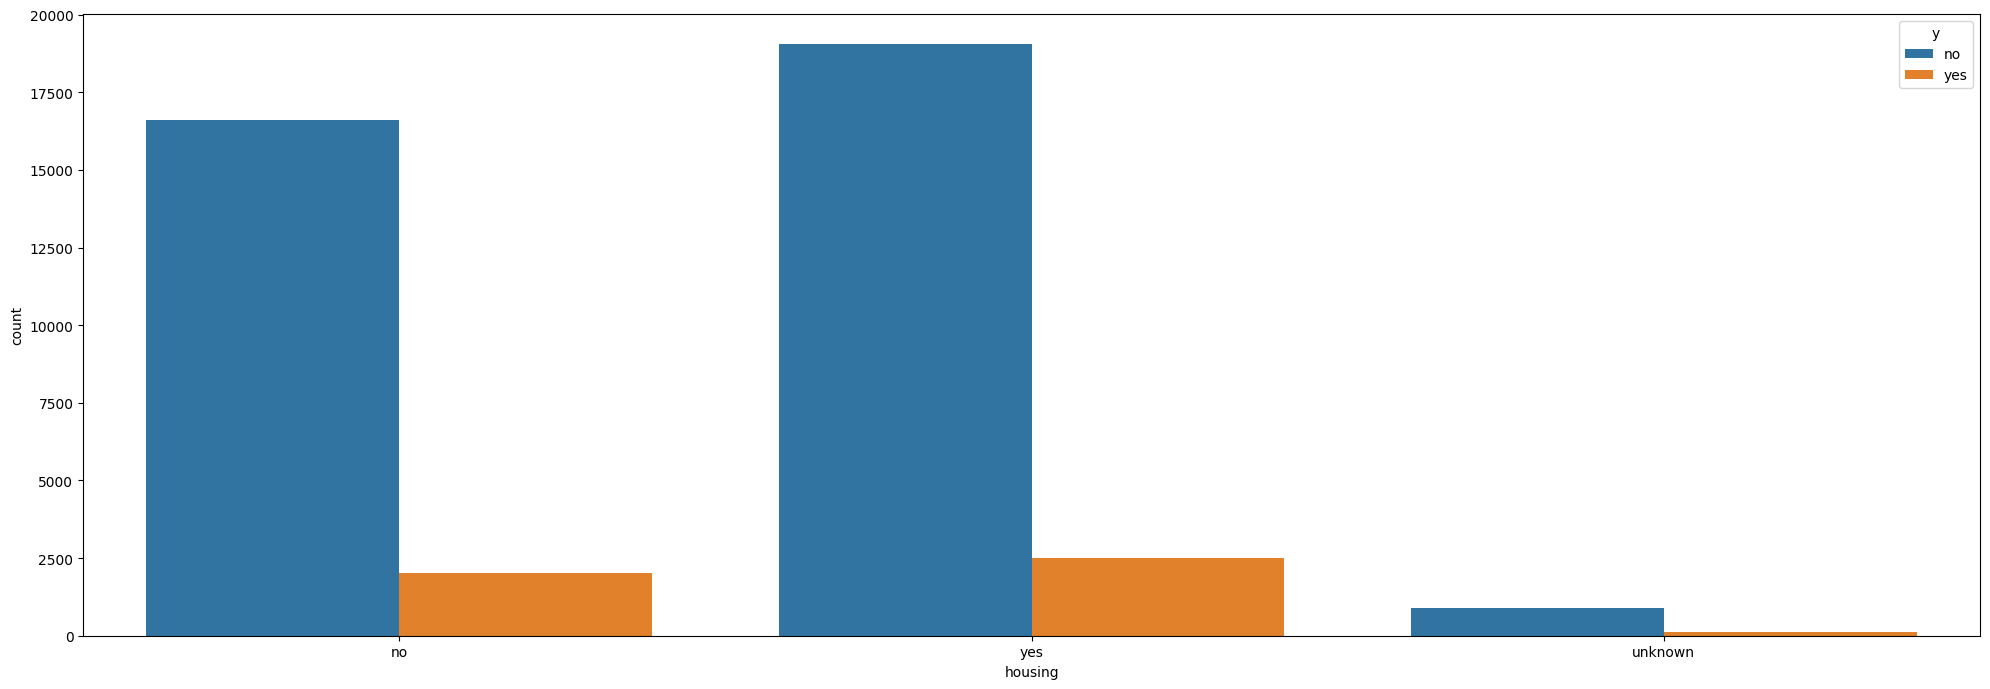

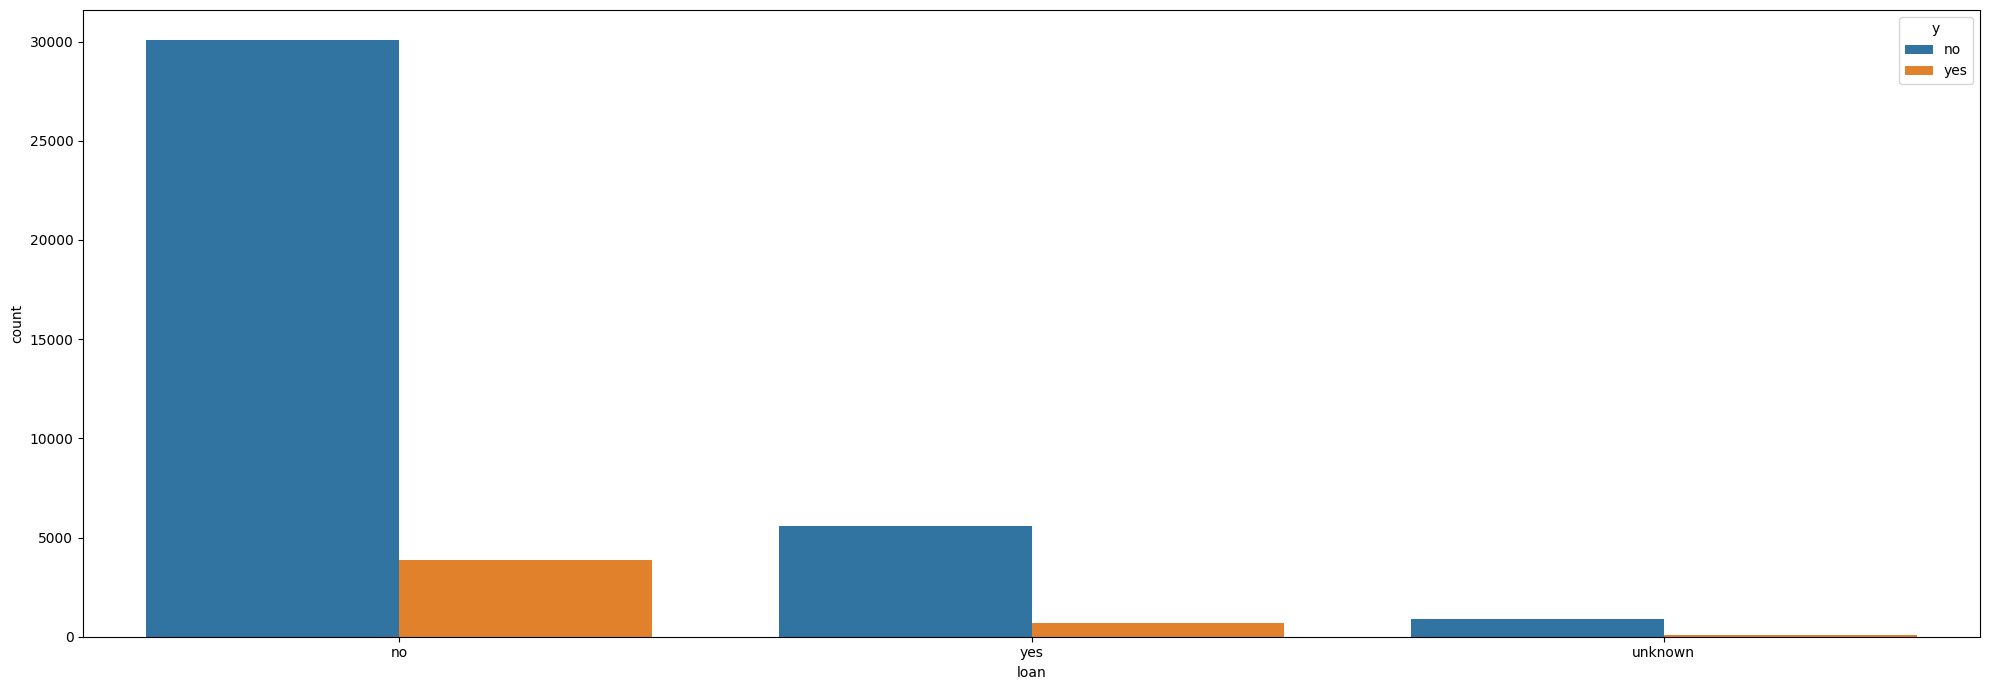

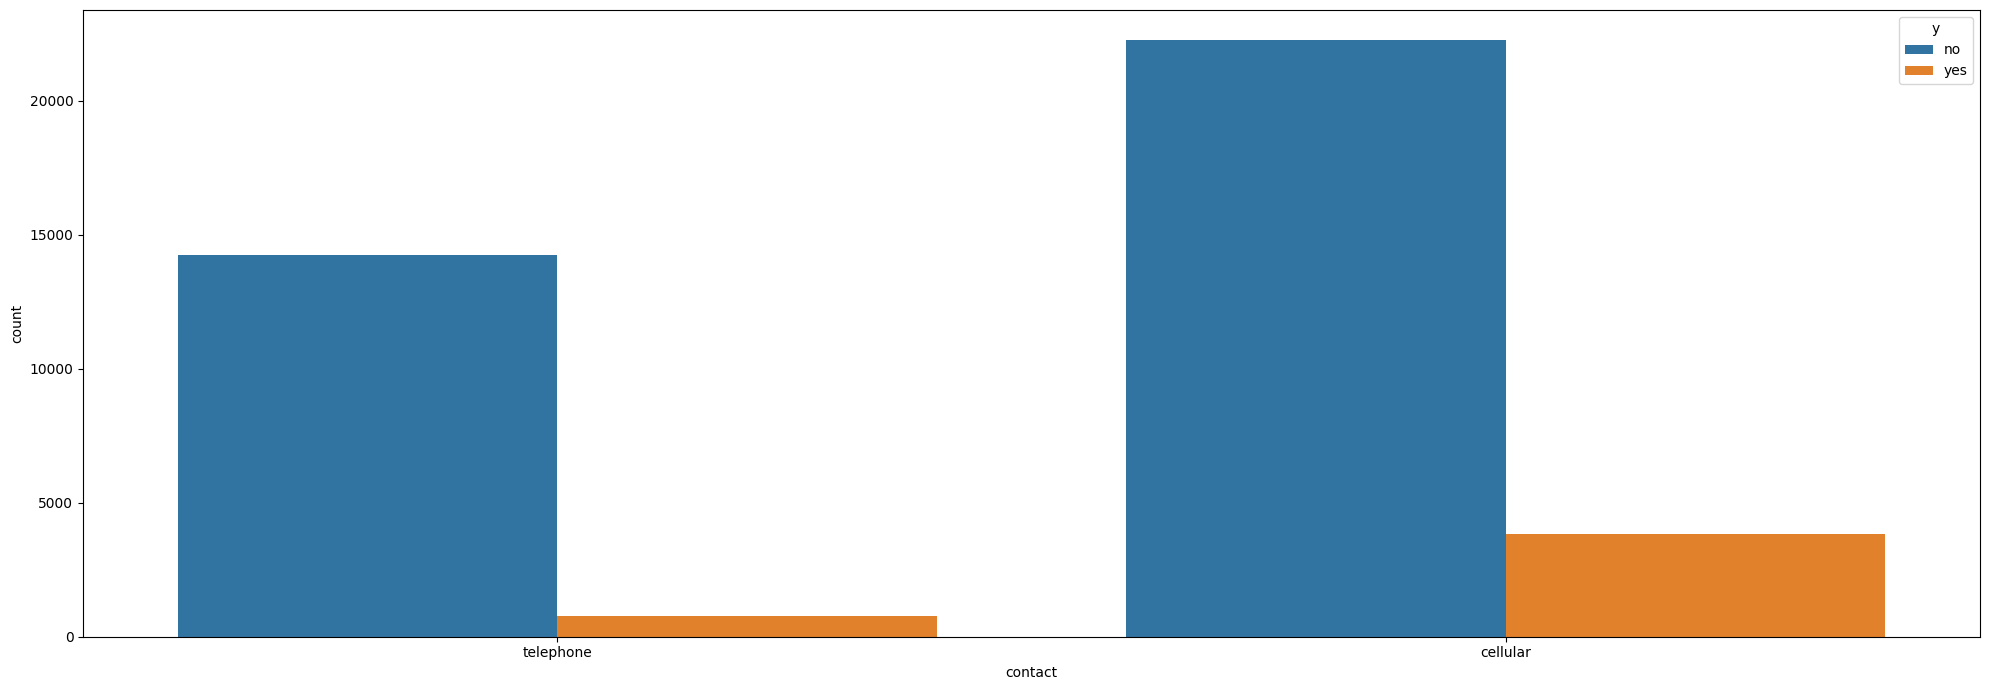

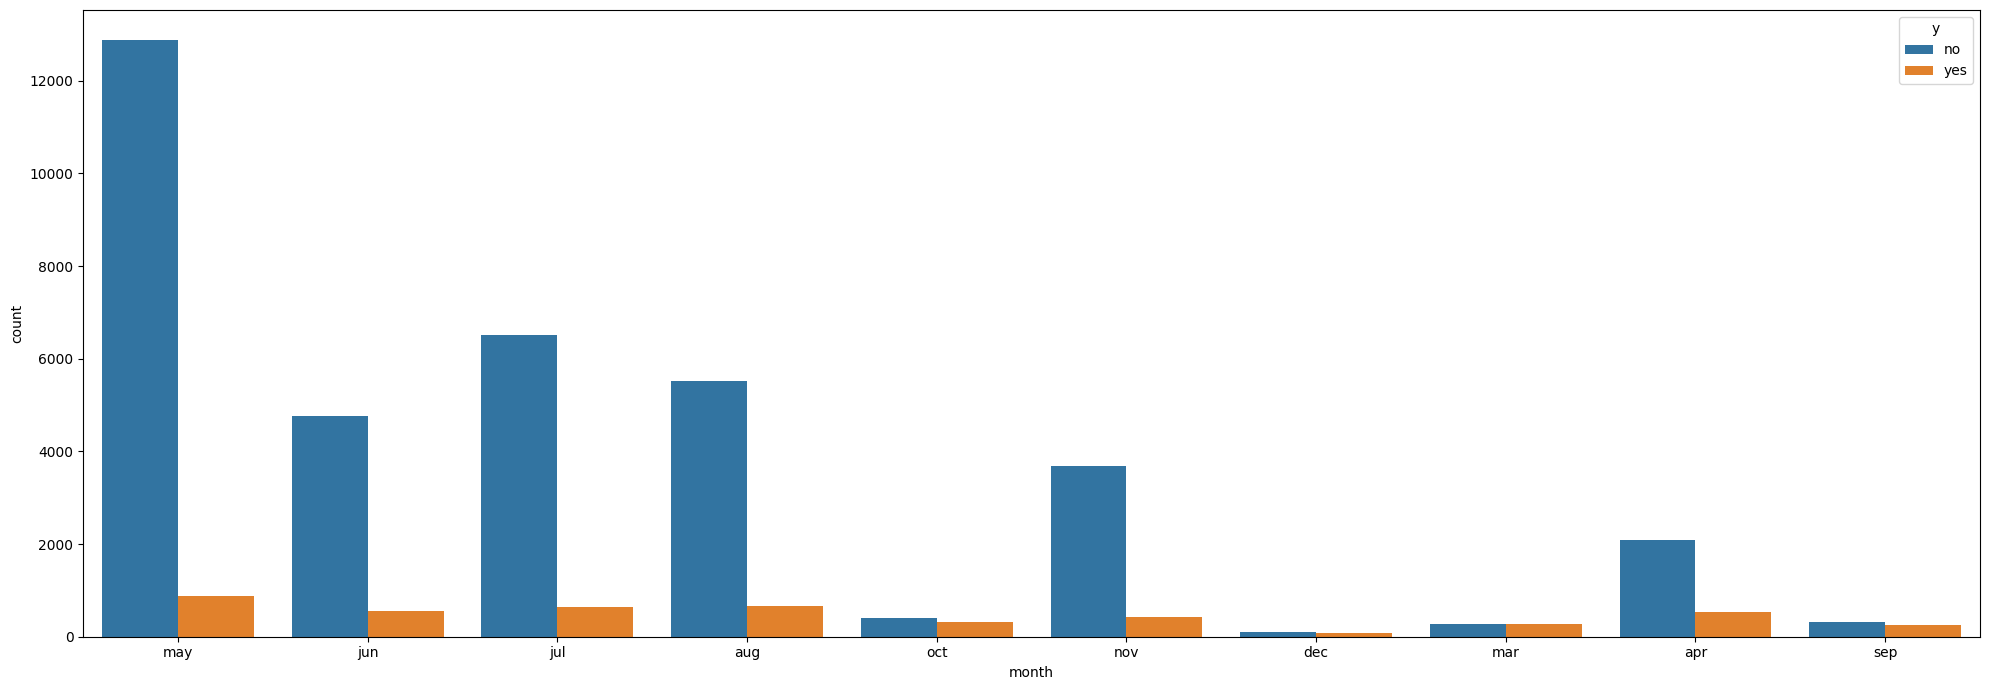

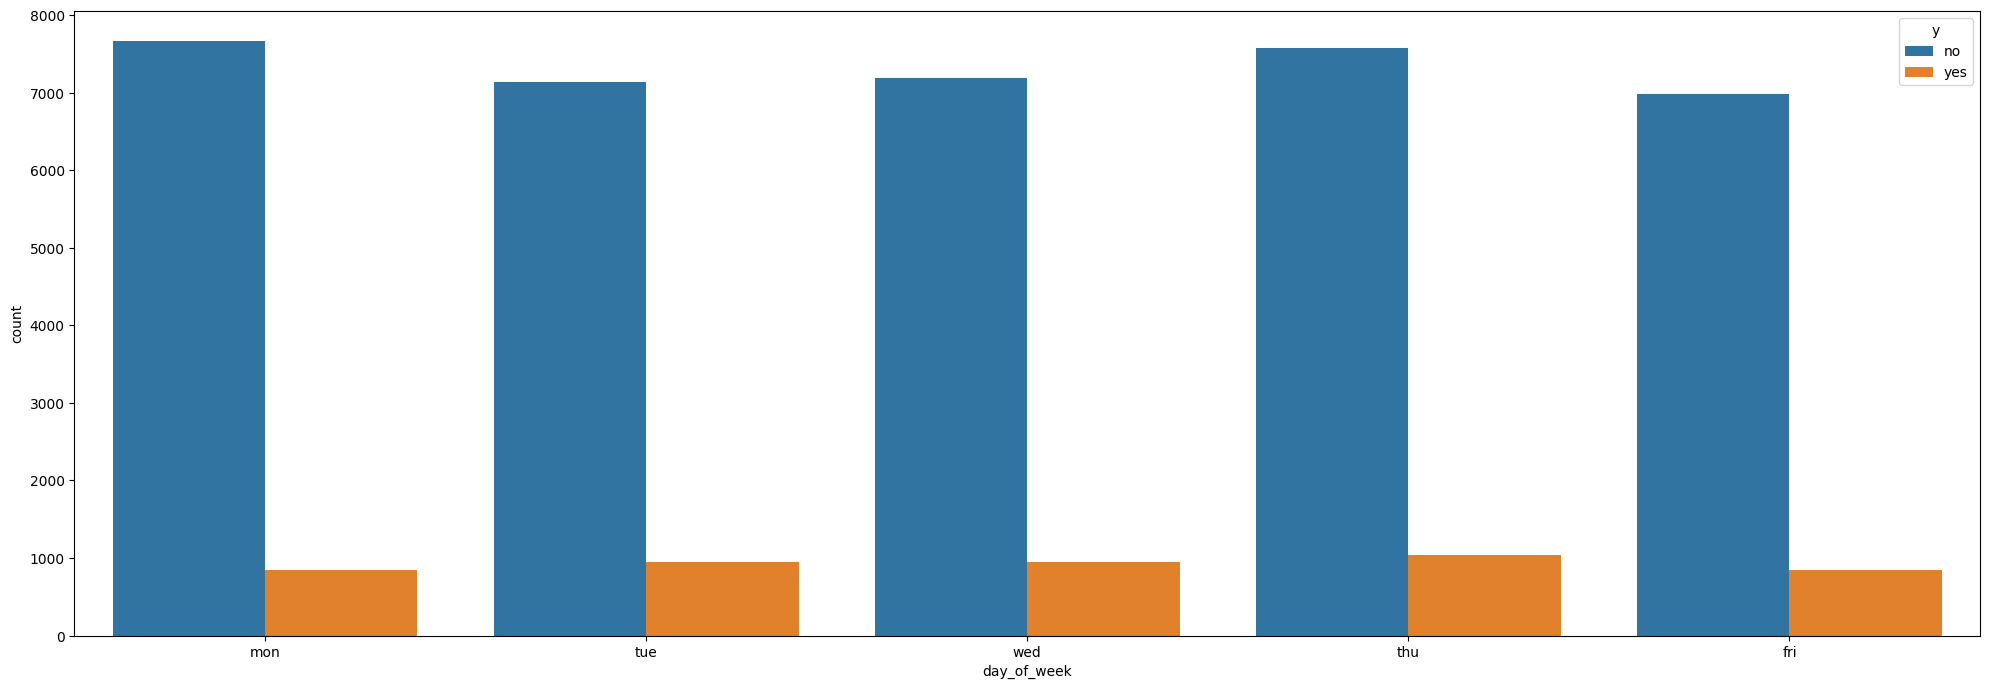

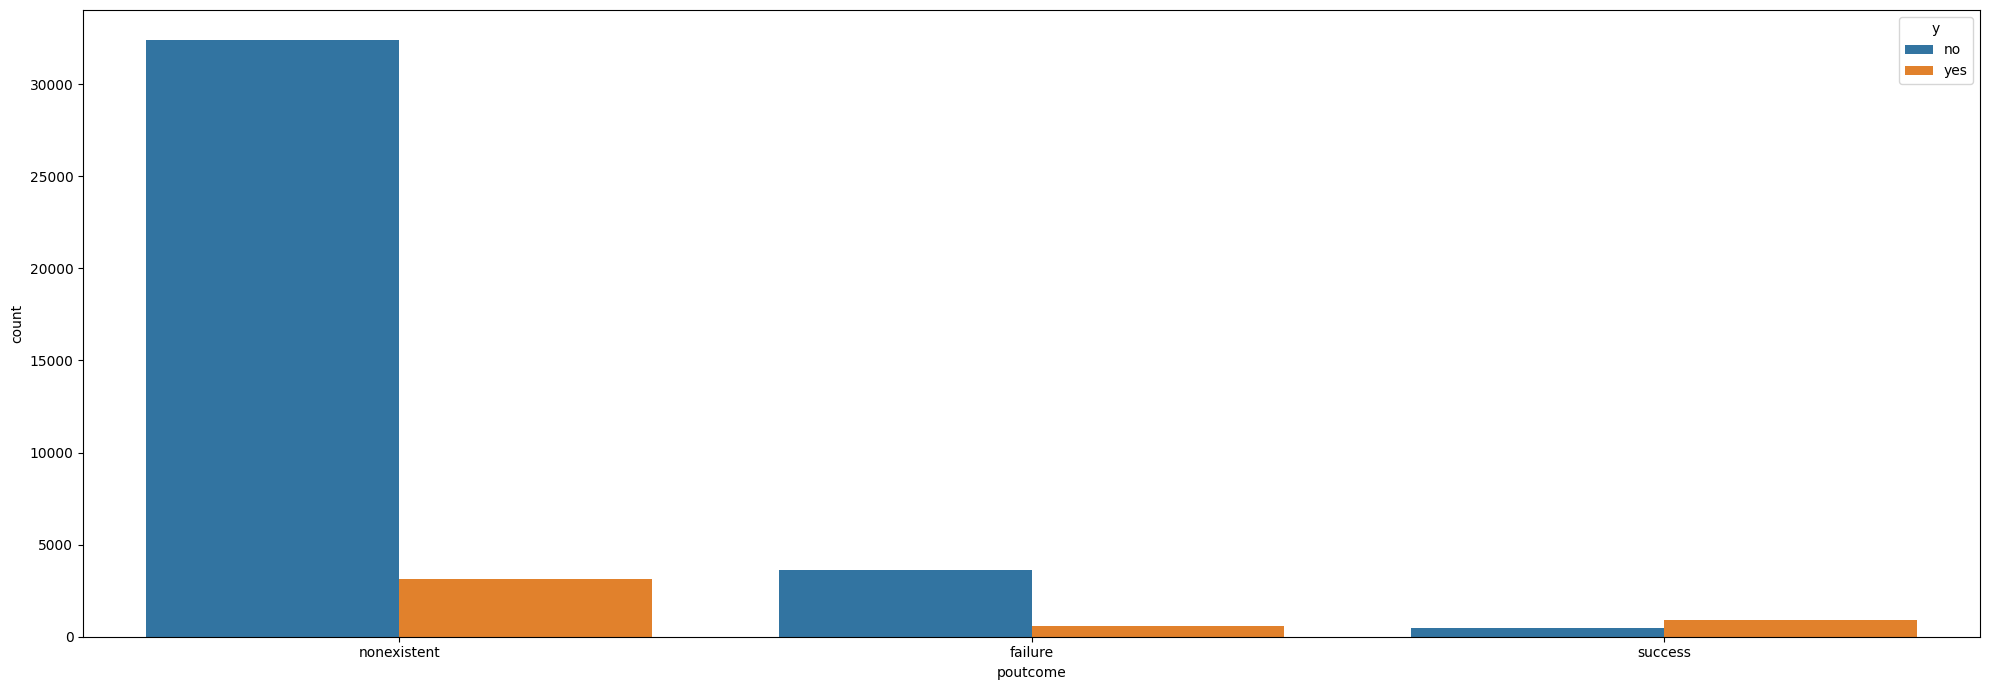

In [67]:
# Bucle para crear gráficos comparando la variable categórica target con el resto de variables 
for column in categorical_discret_cols:
    fig, axis = plt.subplots(figsize=(20, 7))
    sns.countplot(data=df, x=column, hue="y")
    plt.tight_layout()
    plt.show()

#### **Análisis de variables numéricas (Outliers)**

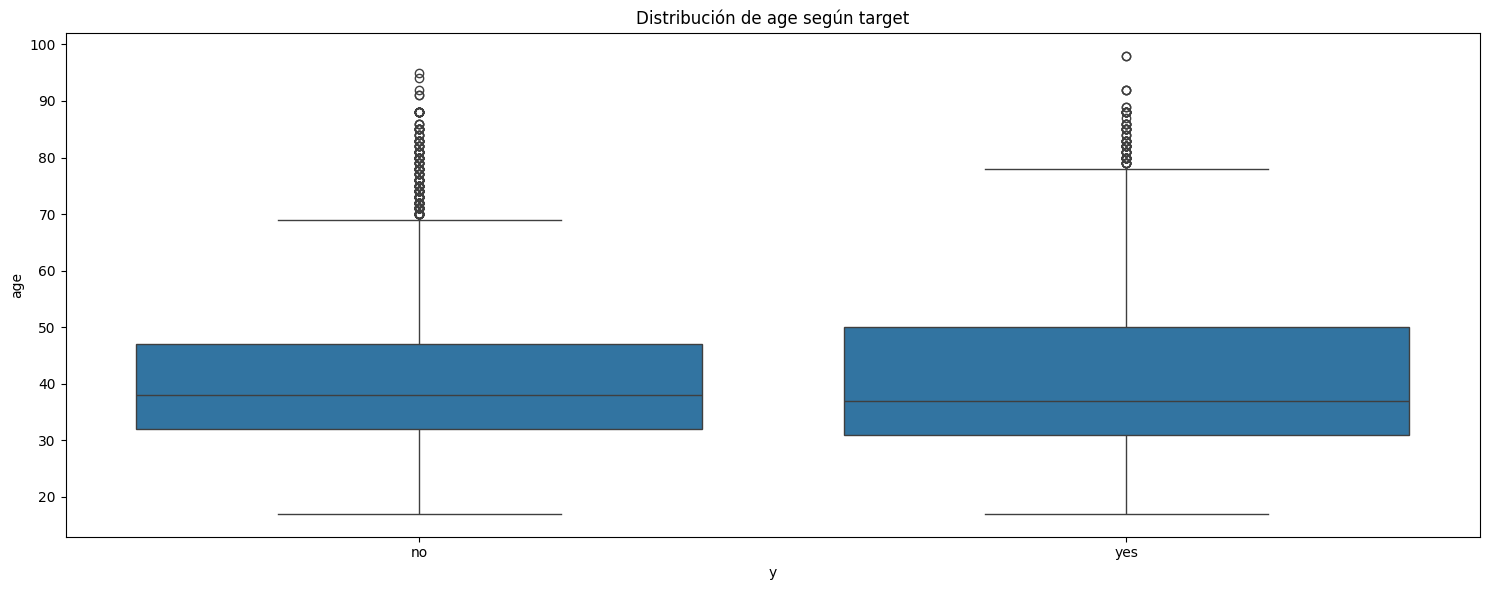

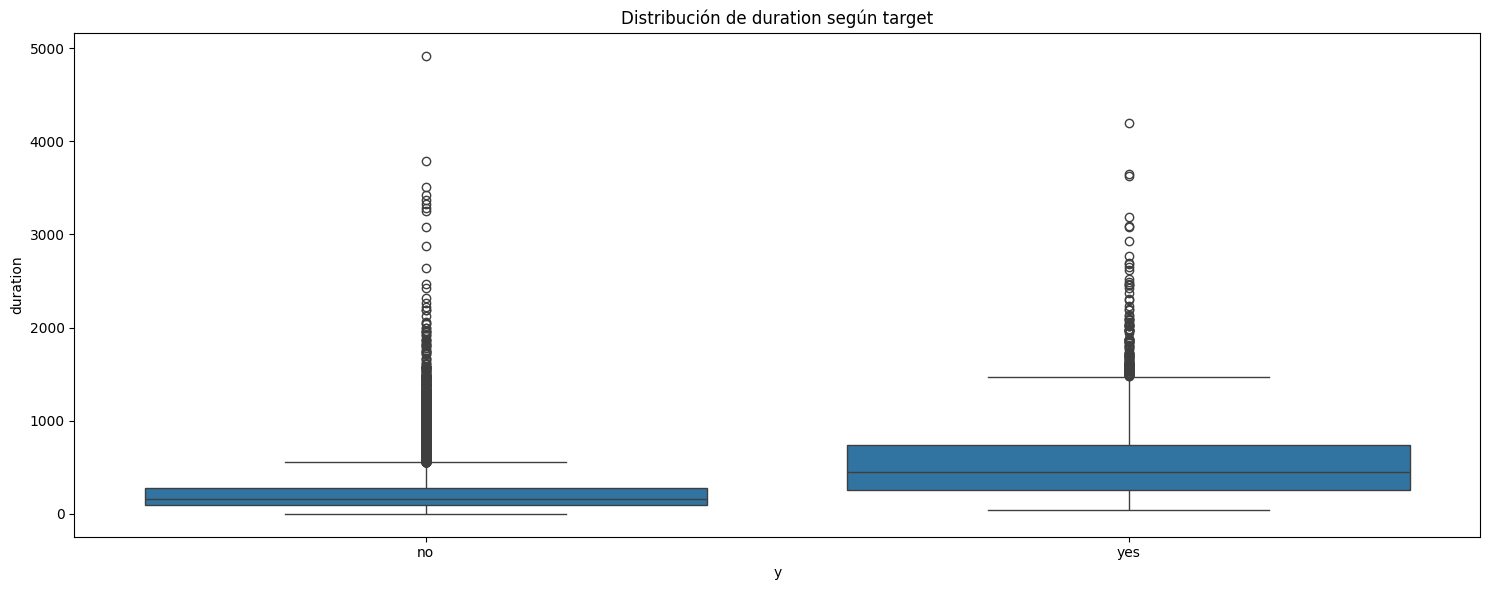

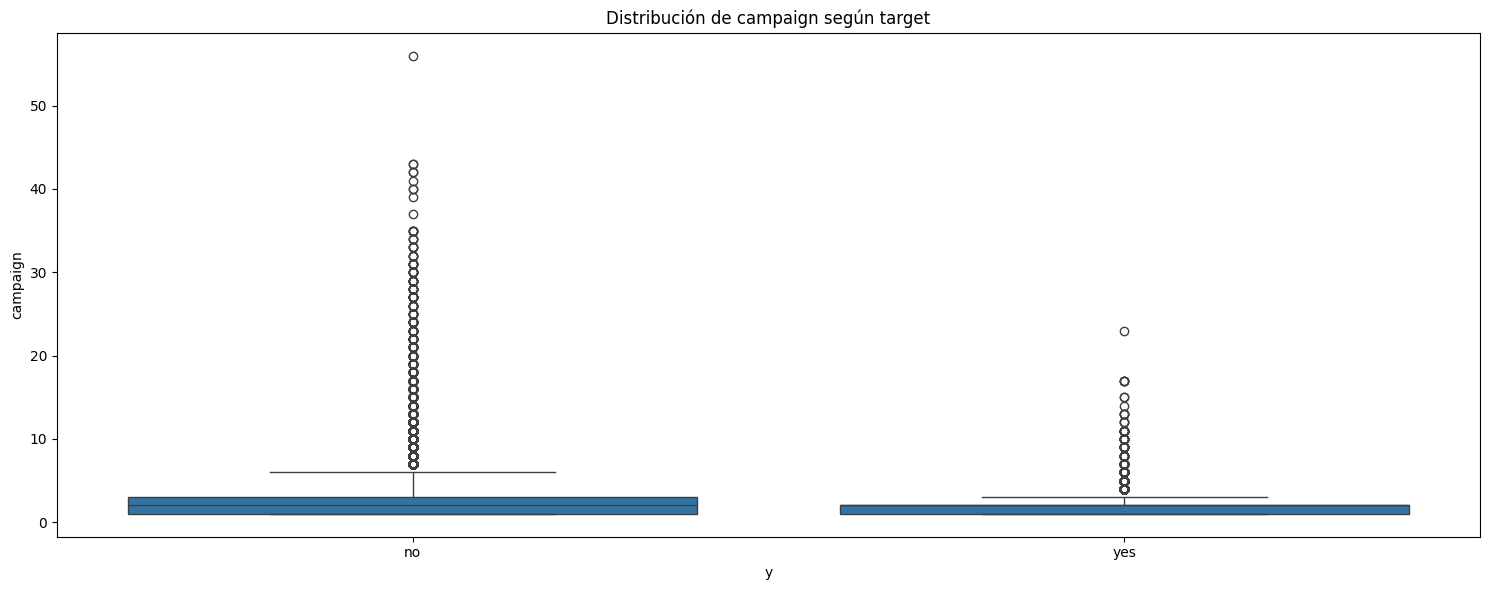

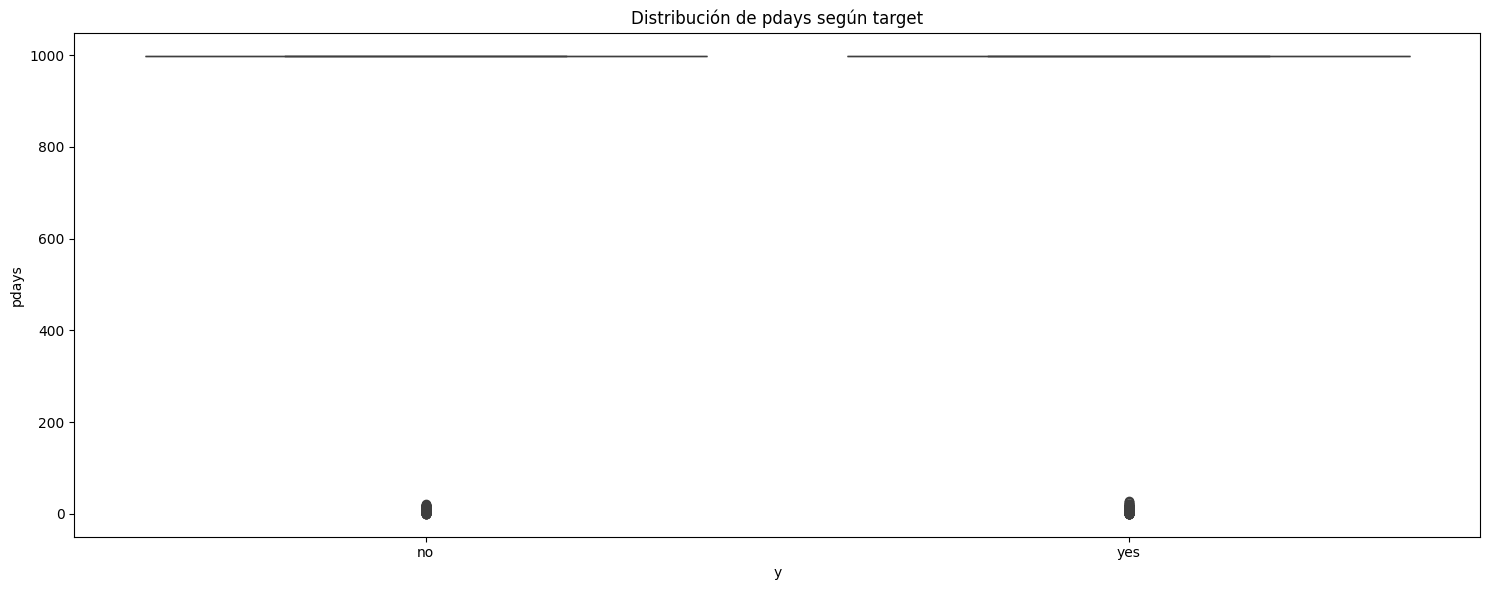

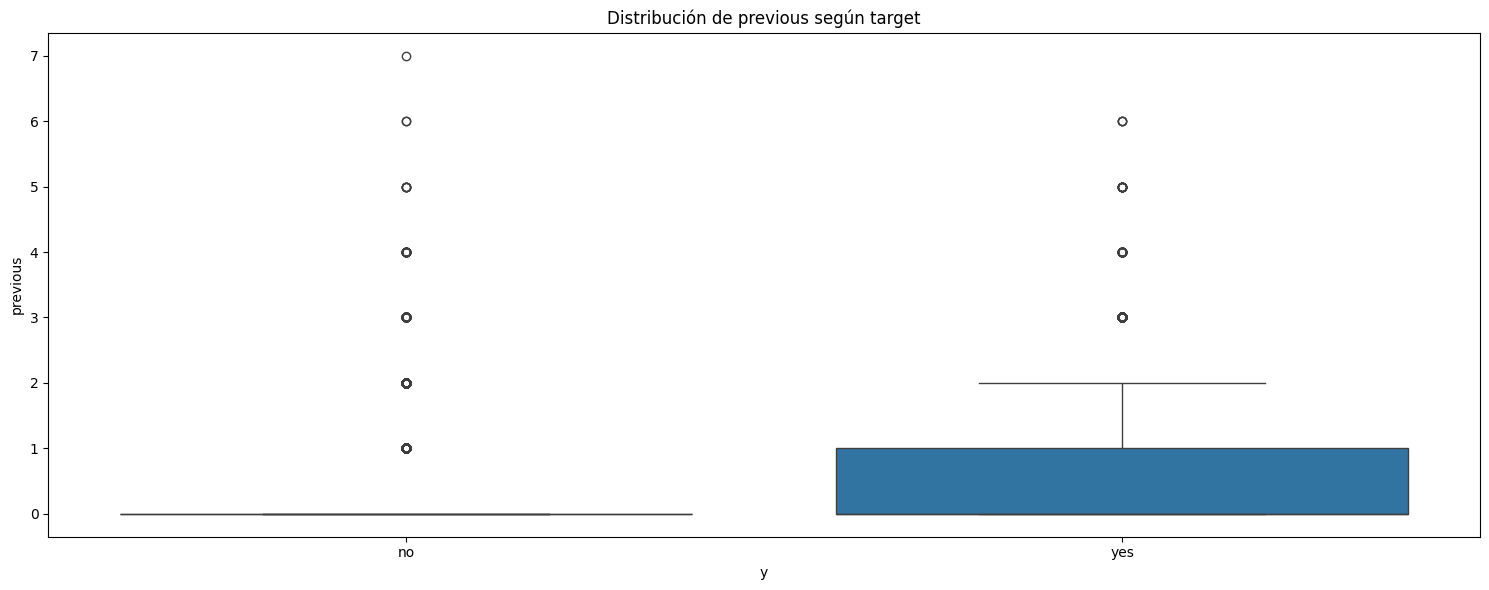

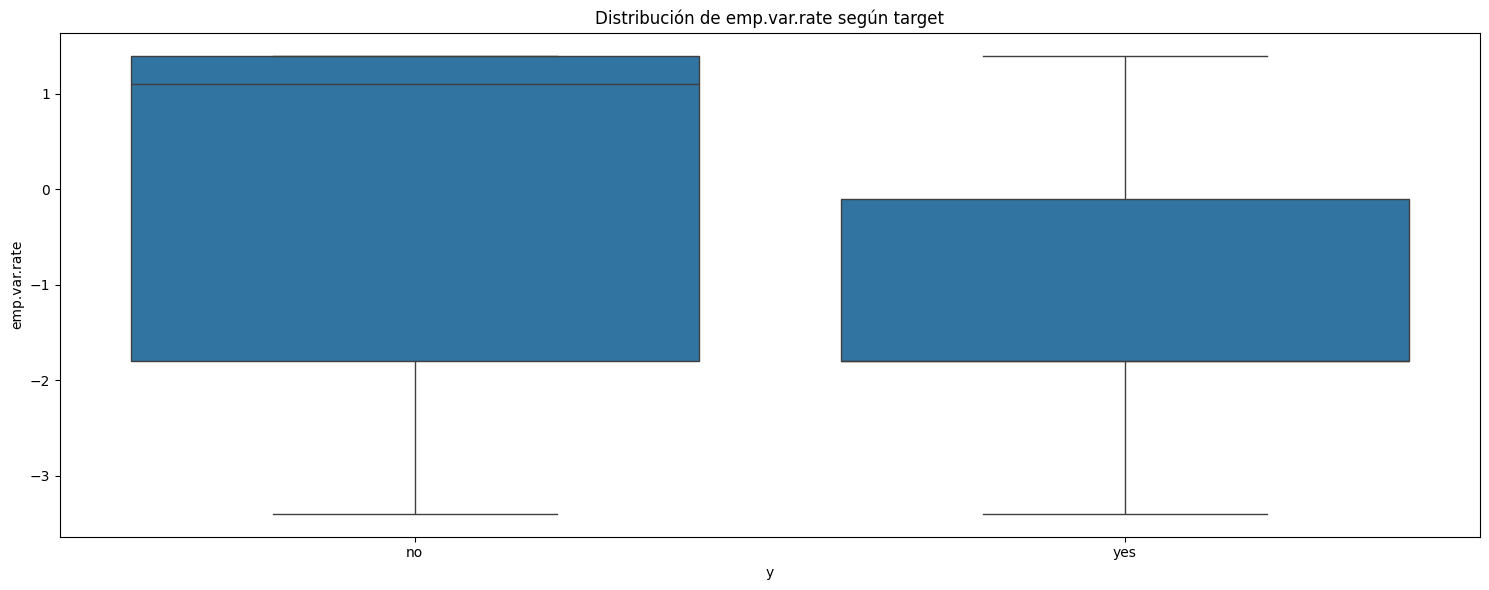

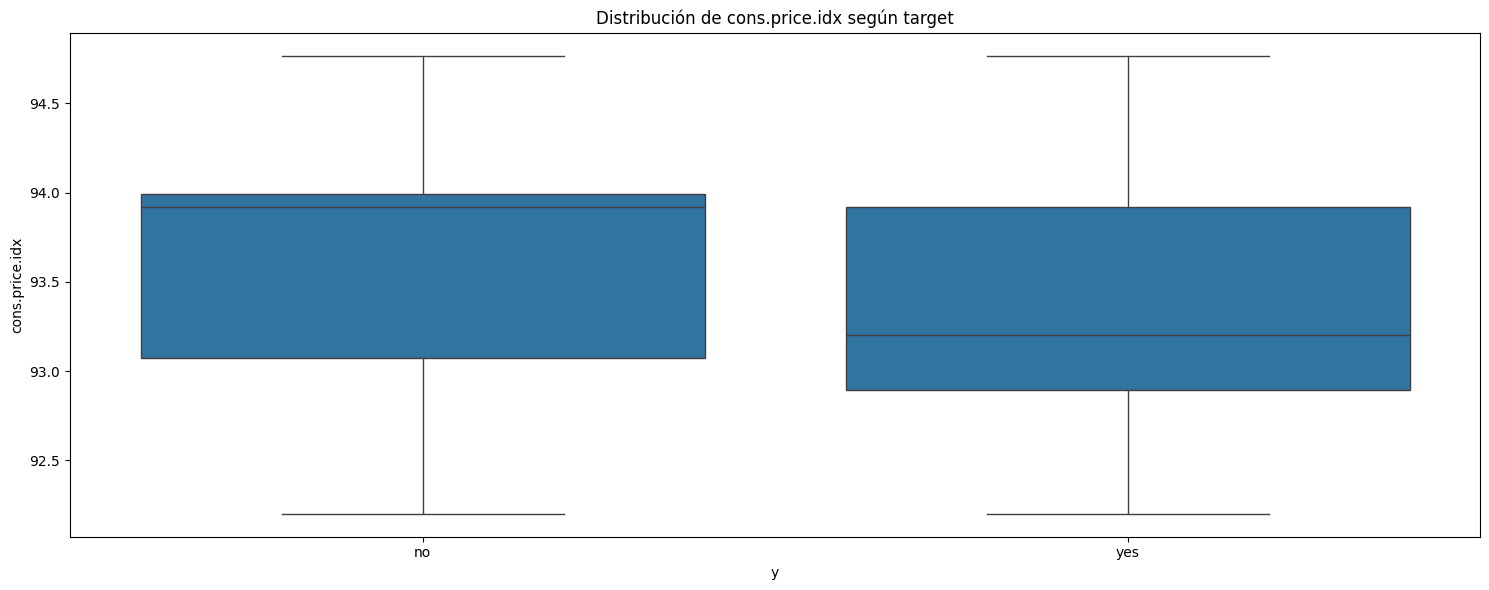

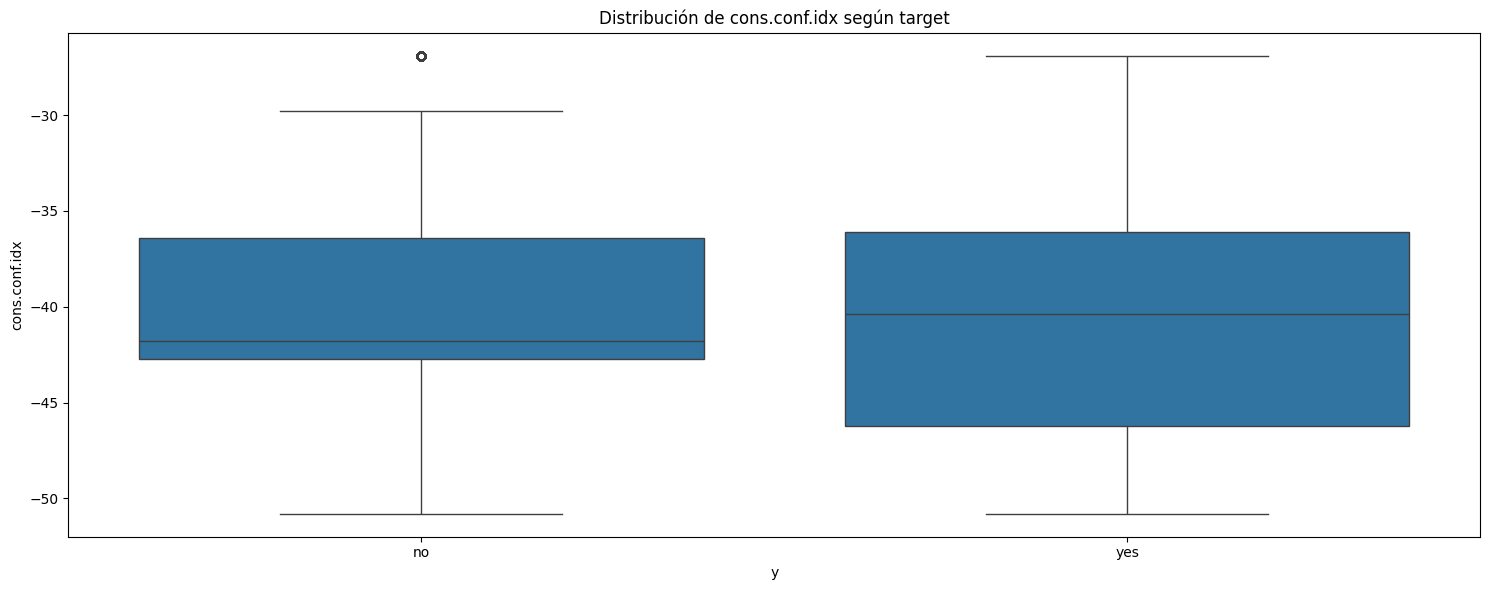

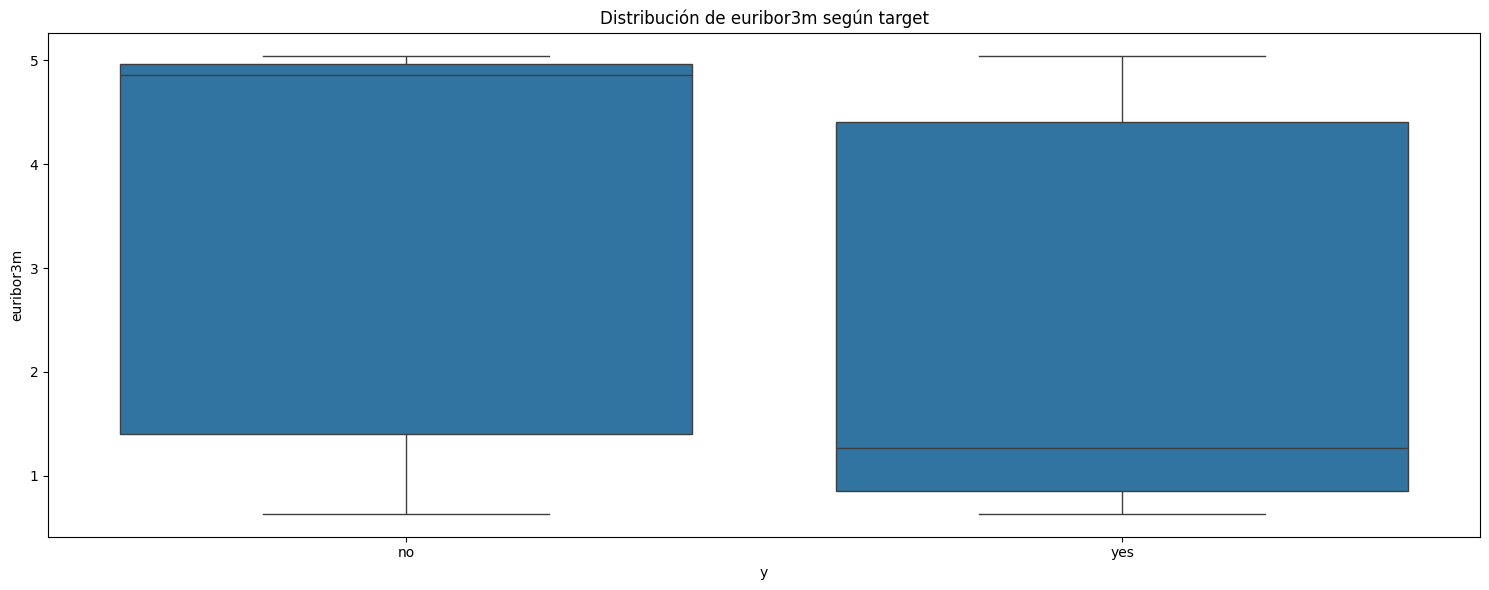

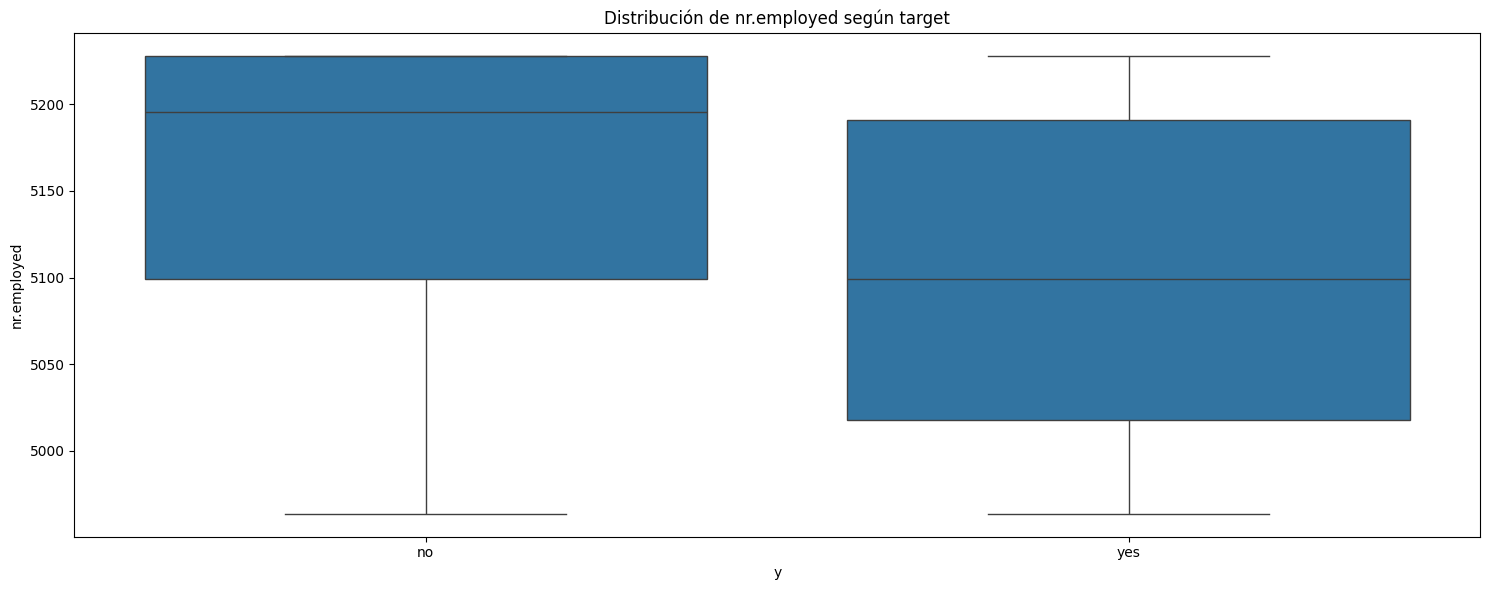

In [68]:
numeric_cols = ["age", "duration", "campaign","pdays", "previous","emp.var.rate", "cons.price.idx","cons.conf.idx", "euribor3m", "nr.employed"]

for columna in numeric_cols:
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df, x='y', y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

### **ANÁLISIS MULTIVARIANTE**

#### **Nota: En el análisis de variables Multivariante**

* Inicio con un Gráfico de Correlacion para ver qué columnas puedo eliminar
* Para hacer el gráfico de correlación debemos factorizar las variables categóricas para relacionar todas las columnas, ya tengan características numéricas o categóricas


#### **Análisis categórico-categórico**

#### **Factorización:**


In [69]:
df_factorize = df.copy()

In [70]:
df_factorize['default_y'] = pd.factorize(df['default'])[0]
df_factorize['matrial_y'] = pd.factorize(df['marital'])[0]
df_factorize['job_y'] = pd.factorize(df['job'])[0]
df_factorize['ducation_y'] = pd.factorize(df['education'])[0]
df_factorize['housing_y'] = pd.factorize(df['housing'])[0]
df_factorize['loan_y'] = pd.factorize(df['loan'])[0]
df_factorize['contact_y'] = pd.factorize(df['contact'])[0]
df_factorize['poutcome_y'] = pd.factorize(df['poutcome'])[0]
df_factorize['y_y'] = pd.factorize(df['y'])[0]

In [71]:
df_numerico = df_factorize.select_dtypes(include=['number'])

#### **Mapas de correlación**

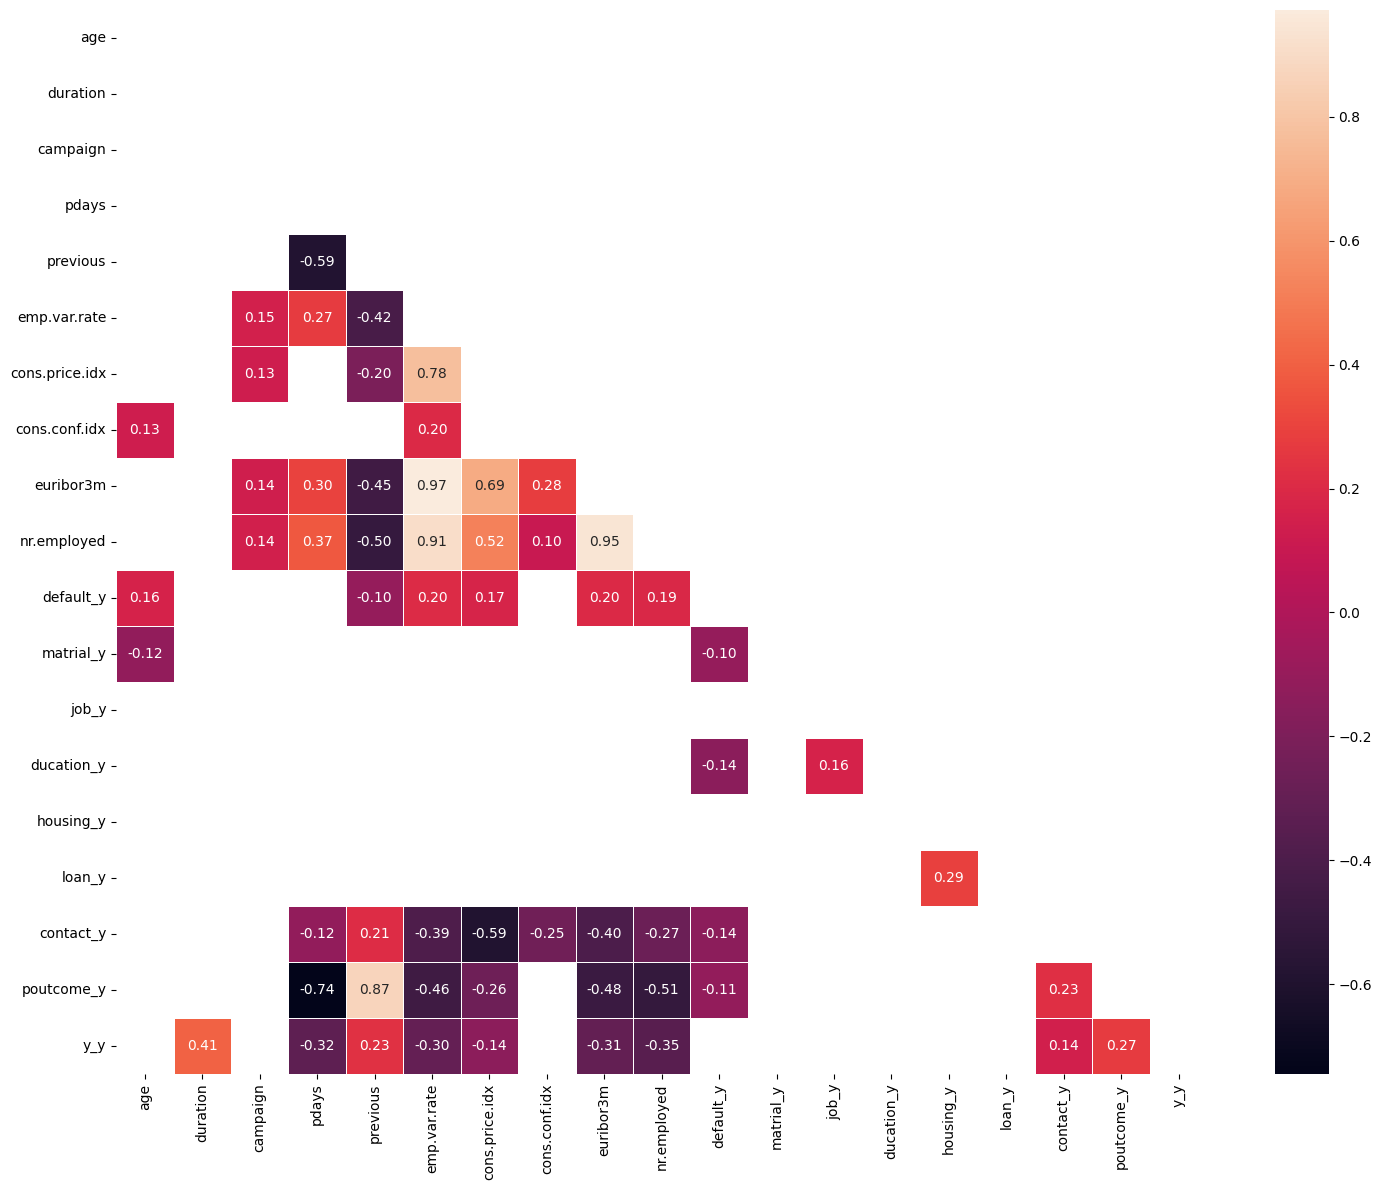

In [72]:
corr = df_numerico.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Conclusiones:**
> * Elimino las siguientes columnas:

In [73]:
df_num_dos = df_numerico.drop(columns=['default_y','poutcome_y','emp.var.rate','nr.employed','cons.price.idx'])
df_num_dos


,age,duration,campaign,pdays,previous,cons.conf.idx,euribor3m,matrial_y,job_y,ducation_y,housing_y,loan_y,contact_y,y_y
0,56,261,1,999,0,-36.4,4.857,0,0,0,0,0,0,0
1,57,149,1,999,0,-36.4,4.857,0,1,1,0,0,0,0
2,37,226,1,999,0,-36.4,4.857,0,1,1,1,0,0,0
3,40,151,1,999,0,-36.4,4.857,0,2,2,0,0,0,0
4,56,307,1,999,0,-36.4,4.857,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-50.8,1.028,0,5,4,1,0,1,1
41184,46,383,1,999,0,-50.8,1.028,0,3,4,0,0,1,0
41185,56,189,2,999,0,-50.8,1.028,0,5,6,1,0,1,0
41186,44,442,1,999,0,-50.8,1.028,0,4,4,0,0,1,1


* **Segundo heatmap para observas las correlaciones:**

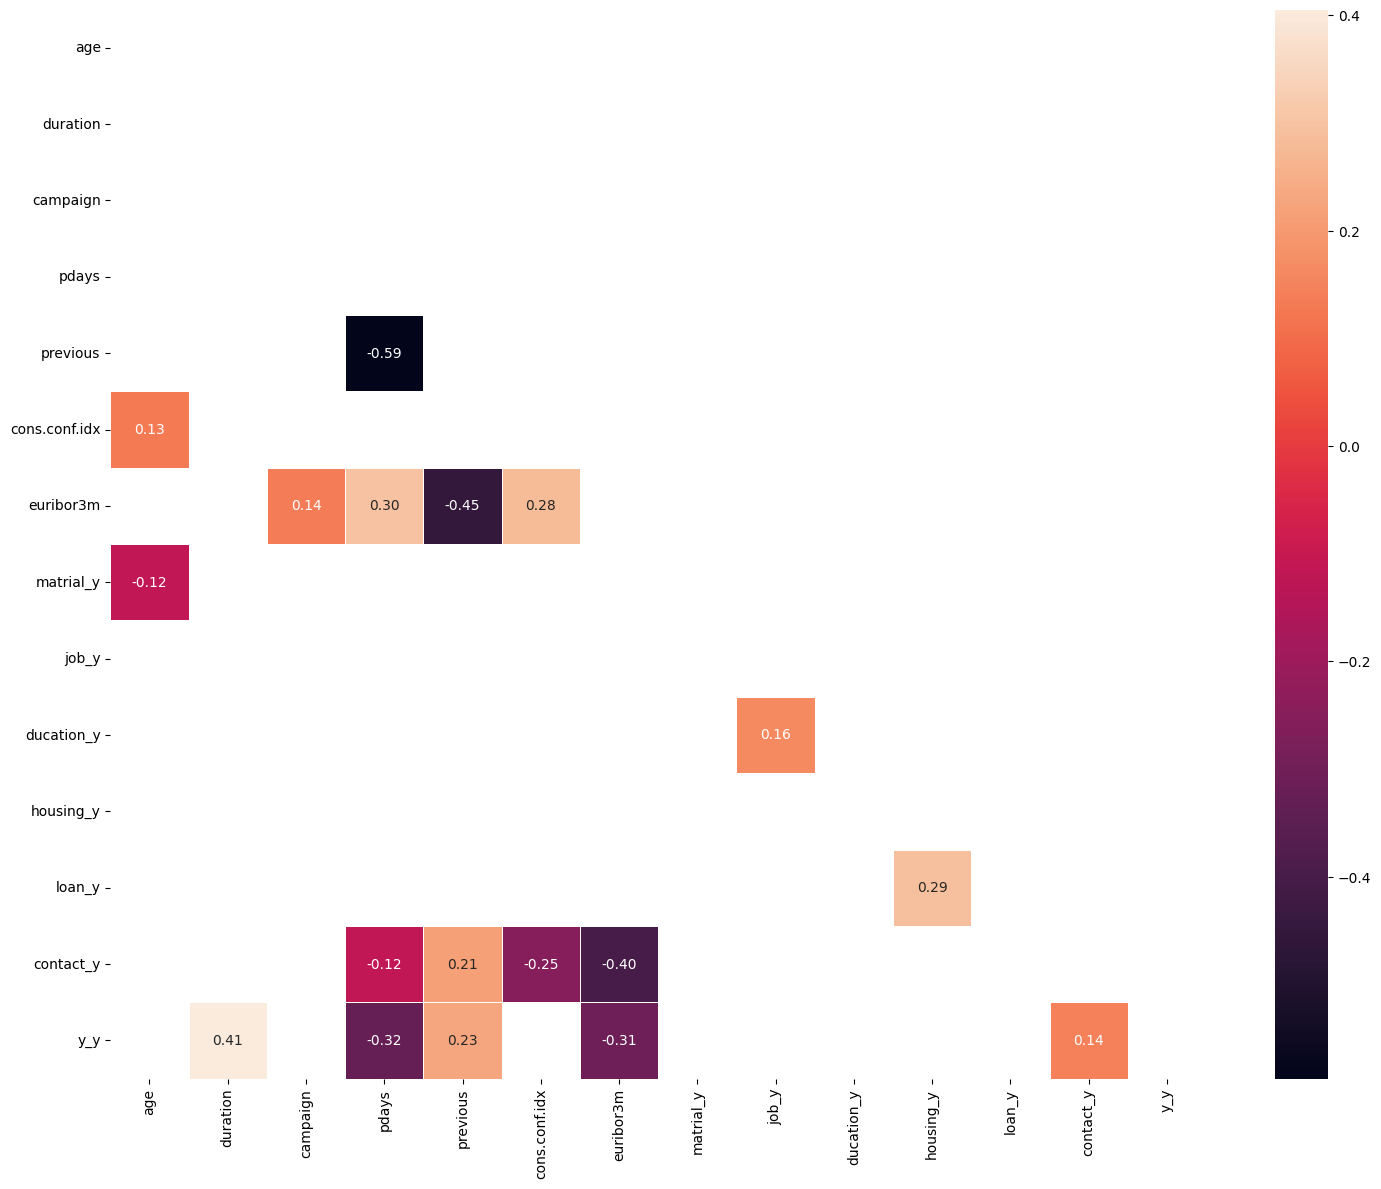

In [74]:
corr = df_num_dos.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

## **Guardado del EDA**

In [ ]:
df_numerico.to_csv("../data/processed/marketing_campaign.csv", index=False)

> Utilizo el df_numerico porque se observan más correlaciones entre los datos.

# **ML Regresión Logística**

## Paso 1: **Read and split data**

In [83]:
df = pd.read_csv("../data/processed/marketing_campaign.csv")

In [84]:
X = df.drop("y", axis=1)
y = df[ "y"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [79]:
X_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
6706,35,blue-collar,divorced,basic.4y,no,yes,yes,telephone,may,wed,433,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
38277,37,technician,married,university.degree,no,yes,no,cellular,oct,wed,364,1,999,1,failure,-3.4,92.431,-26.9,0.742,5017.5
25853,34,admin.,married,university.degree,no,yes,no,cellular,nov,wed,174,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8
20616,33,admin.,single,university.degree,no,no,no,cellular,aug,wed,159,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1
27936,32,admin.,single,university.degree,no,unknown,unknown,cellular,mar,mon,77,3,999,0,nonexistent,-1.8,92.843,-50.0,1.520,5099.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5294,41,self-employed,married,university.degree,no,yes,no,telephone,may,fri,150,6,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1726,33,technician,married,professional.course,no,no,no,telephone,may,fri,205,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0
35653,37,admin.,divorced,university.degree,unknown,yes,no,cellular,may,mon,442,1,999,0,nonexistent,-1.8,92.893,-46.2,1.244,5099.1
25720,45,admin.,married,high.school,no,yes,no,cellular,nov,wed,90,1,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8


## Paso 2: **Generar modelo inicial**

In [86]:
model = LogisticRegression(random_state=42)
model.fit(X_train,y_train) # Se entrena el modelo


ValueError: could not convert string to float: 'blue-collar'

In [ ]:
X_test.shape

### **Predicciones del Modelo**

In [ ]:
y_pred = model.predict(X_test)
y_pred

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [ ]:
y_pred = model.predict(X_test)
y_pred

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

* **Ajuste del umbral de decisión**

In [ ]:
# Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
y_proba = model.predict_proba(X_test)

# Suponiendo que deseas ajustar el umbral a 0.3
threshold = 0.3
y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# Evaluar el rendimiento con el nuevo umbral
accuracy_score(y_test, y_pred_threshold)

### **Métricas**

* **Accuracy:** Es la fracción de predicciones que el modelo realizó correctamente.

In [ ]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

## Paso 3: **Hiperparametrización**


In [ ]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadrícula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

### **GridSearch:**

In [ ]:
best_model_grid = LogisticRegression(penalty='l1',
                                     C=1,
                                     solver='liblinear')
best_model_grid.fit(X_train, y_train)
best_model_grid = grid.best_estimator_


In [ ]:
y_pred_grid = best_model_grid.predict(X_train)

grid_accuracy = accuracy_score(y_train, y_pred_grid)

model_accuracy, grid_accuracy

In [ ]:
grid_accuracy - model_accuracy # COMPARACION

### **Randomized SreachCV:**

In [ ]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=18)
random_search

In [ ]:
random_search.fit(X_train, y_train)

random_search.best_params_

> **Observaciones:**
> Como vemos, los parámetros optimizados utilizando esta técnica son:  
>               - `C`: 29.7635  
>               - `penalty`: l2  
>               - `solver`: lbfgs  
> Con esta nueva hiperparametrización, reentrenamos el modelo:

In [ ]:
model_random_search = LogisticRegression(penalty="l2",
                                         C=29.7635,
                                         solver="lbfgs")

model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

**Observaciones:**
DUDAS: compara resutlados!!

## Paso 4: **Matriz de confusión**

Además de la puntuación (*score*) del modelo observada, es común que en los problemas de clasificación se construya una **matriz de confusión** (*confusion matrix*), que es una tabla que se organiza de tal manera que cada fila de la matriz representa las instancias de una clase predicha, mientras que cada columna representa las instancias de una clase real:


In [ ]:
rl_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(rl_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

## Paso 5: **Guardado de data**

In [ ]:
# Guardamos utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/logistic-regression-label-encoder.pkl', 'wb') as file:
    pickle.dump(onehot_encoder, file)
